Importation des librairies

In [13]:
import sys
import joblib
sys.path.append('..')
from pathlib import Path
from src.imports import *
from src.utilitaires import load_data

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

import warnings
warnings.filterwarnings('ignore')

CHARGEMENT DES DONNEES

In [3]:
X_train, X_test, y_train, y_test = load_data()

DÉFINITION DES MODÈLES

In [4]:
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Arbre de Décision": DecisionTreeClassifier(random_state=42),
}

ENTRAÎNEMENT, ÉVALUATION 

In [5]:
trained_models = {}
predictions_cache = {}
results = []

print("--- Entraînement et Évaluation ---")
for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} entraîné")

    # MODIFICATION : Un seul calcul de prédiction stocké en mémoire
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Stockage dans le cache pour réutilisation immédiate dans les graphiques
    predictions_cache[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
    }

    # Stockage des métriques pour le tableau final
    results.append({
        "Modèle": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc, 4),
    })

# Affichage du tableau récapitulatif trié
df_results = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
print("\n📊 Tableau des performances :")
print(df_results)



--- Entraînement et Évaluation ---
✅ Régression Logistique entraîné
✅ Random Forest entraîné
✅ SVM entraîné
✅ KNN entraîné
✅ Arbre de Décision entraîné

📊 Tableau des performances :
                  Modèle  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0          Random Forest    0.8997     0.9925  0.7804    0.8738   0.8991
1      Arbre de Décision    0.8251     0.7901  0.8264    0.8078   0.8252
2                    SVM    0.8290     0.9109  0.6825    0.7803   0.8674
3                    KNN    0.7980     0.8498  0.6632    0.7450   0.8319
4  Régression Logistique    0.7307     0.7091  0.6691    0.6885   0.8013


VISUALISATION : MATRICES DE CONFUSION (Utilisation du cache)


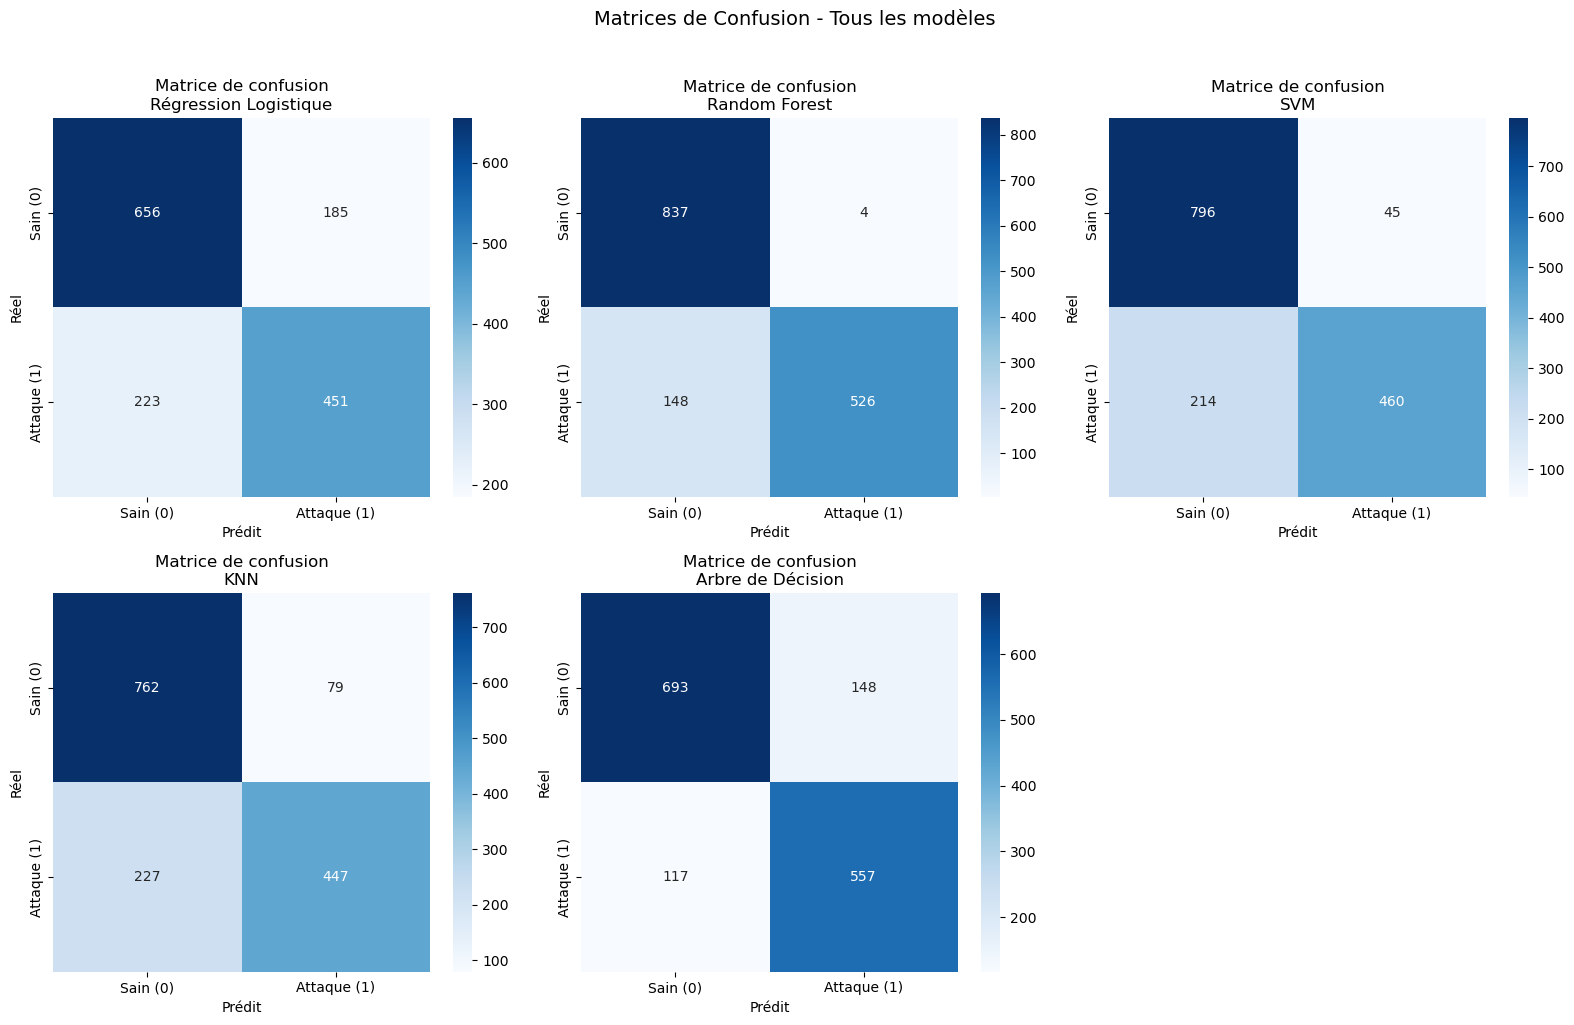

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, name in enumerate(trained_models.keys()):
    y_pred_cached = predictions_cache[name]['y_pred']  # Récupération depuis le cache
    cm = confusion_matrix(y_test, y_pred_cached)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Sain (0)', 'Attaque (1)'],
        yticklabels=['Sain (0)', 'Attaque (1)'],
    )
    axes[i].set_title(f"Matrice de confusion\n{name}")
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")

axes[-1].set_visible(False)  # Cache le 6ème slot vide
plt.suptitle("Matrices de Confusion - Tous les modèles", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



VISUALISATION : COURBES ROC (Utilisation du cache)

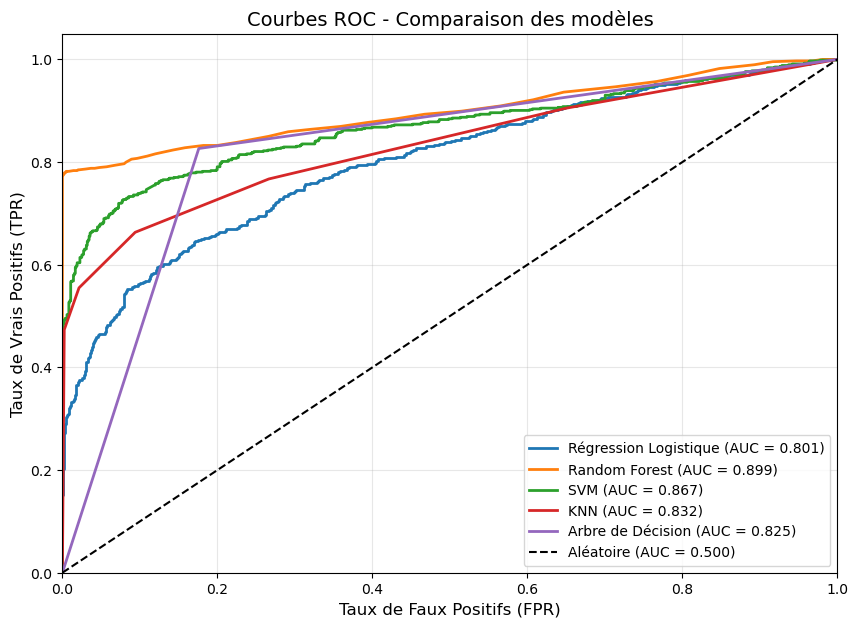

In [7]:
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for name, color in zip(trained_models.keys(), colors):
    cache = predictions_cache[name]  # Récupération depuis le cache
    plt.plot(
        cache['fpr'],
        cache['tpr'],
        color=color,
        lw=2,
        label=f"{name} (AUC = {cache['roc_auc']:.3f})",
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Aléatoire (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de Faux Positifs (FPR)", fontsize=12)
plt.ylabel("Taux de Vrais Positifs (TPR)", fontsize=12)
plt.title("Courbes ROC - Comparaison des modèles", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


VISUALISATION : COMPARAISON DES SCORES

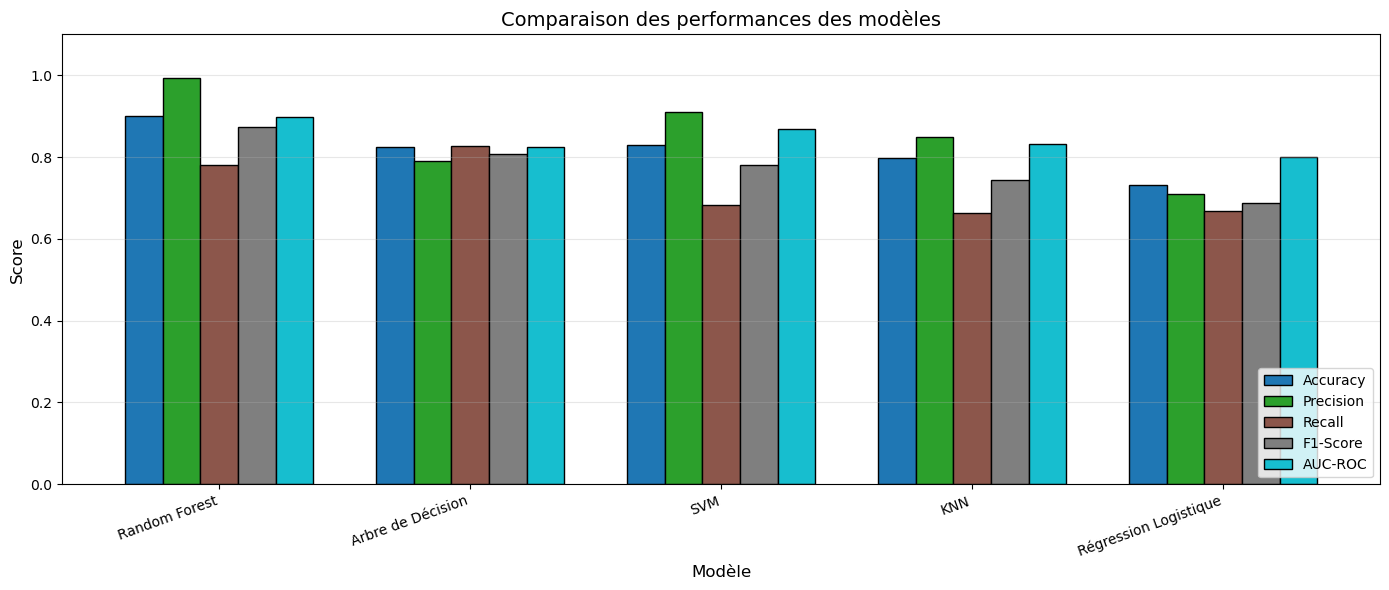

In [8]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
df_plot = df_results.set_index("Modèle")[metrics]

df_plot.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='black', width=0.75)
plt.title("Comparaison des performances des modèles", fontsize=14)
plt.xlabel("Modèle", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



VISUALISATION : IMPORTANCE DES ATTRIBUTS (Random Forest)

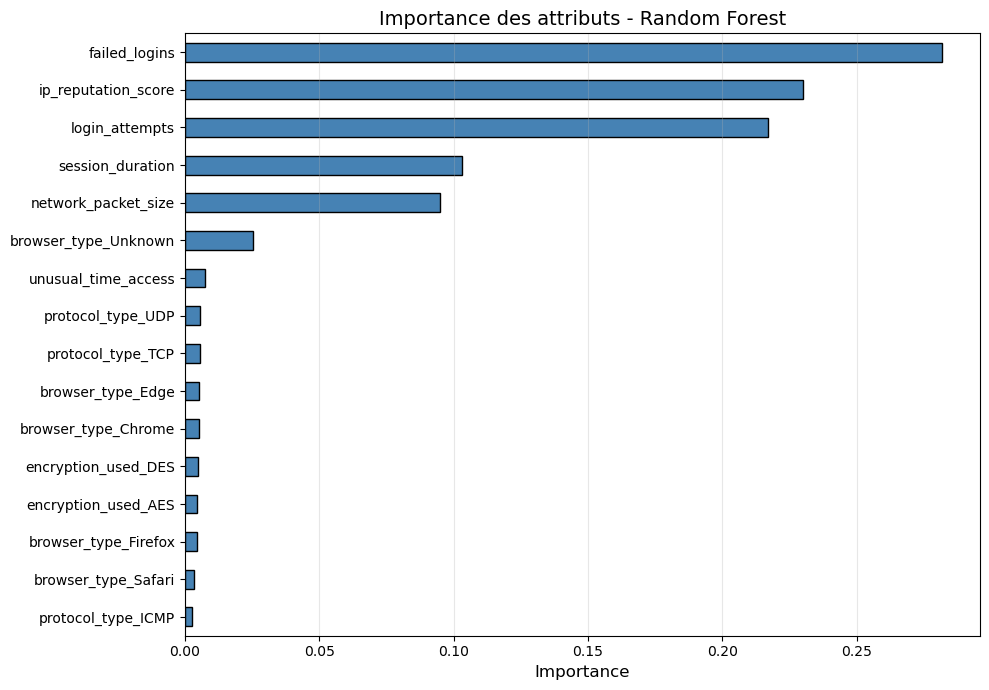


Top 5 attributs les plus importants (Random Forest) :
failed_logins          0.281842
ip_reputation_score    0.230103
login_attempts         0.216866
session_duration       0.102989
network_packet_size    0.094781
dtype: float64


In [9]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Importance des attributs - Random Forest", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 attributs les plus importants (Random Forest) :")
print(importances.sort_values(ascending=False).head())



RAPPORT DE CLASSIFICATION DU MEILLEUR MODÈLE

In [10]:
best_model_name = df_results.iloc[0]["Modèle"]
best_model = trained_models[best_model_name]
y_pred_best = predictions_cache[best_model_name]['y_pred']  # Récupération depuis le cache

print(f"\n=== Meilleur modèle basé sur le F1-Score : {best_model_name} ===")
print()
print(classification_report(y_test, y_pred_best, target_names=["Sain (0)", "Attaque (1)"]))




=== Meilleur modèle basé sur le F1-Score : Random Forest ===

              precision    recall  f1-score   support

    Sain (0)       0.85      1.00      0.92       841
 Attaque (1)       0.99      0.78      0.87       674

    accuracy                           0.90      1515
   macro avg       0.92      0.89      0.90      1515
weighted avg       0.91      0.90      0.90      1515



SAUVEGARDE DYNAMIQUE DU MEILLEUR MODÈLE

In [14]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Génère un nom de fichier propre basé sur le nom du vainqueur 
nom_fichier_modele = f"{best_model_name.lower().replace(' ', '_')}_model.joblib"
joblib.dump(best_model, model_dir / nom_fichier_modele)

print(
    f"\n✅ Le meilleur modèle absolu ({best_model_name}) a été enregistré avec succès sous '{nom_fichier_modele}'."
)


✅ Le meilleur modèle absolu (Random Forest) a été enregistré avec succès sous 'random_forest_model.joblib'.


In [ ]:
joblib.dump(scaler, model_dir / "scaler.joblib")